## Ahmed Series One

In [6]:
from experiment_analysis import experiments_from_series

In [38]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import os

# ---- choose experiments ----
series_ids = [40]
experiments = experiments_from_series(series_ids)
print(experiments)
# ----------------------------

metric = "requests_running"
MAX_REQUEST_CAPACITY = 64
SMOOTHING_WINDOW_S = 30

agg_mode = "sum"
# agg_mode = "mean"

# ---- magnifier zoom window in TIME ----
ZOOM_T_START = 8000
ZOOM_T_END   = 8060

# ---- inset box placement in AXES coordinates (guaranteed inside) ----
# [x0, y0, width, height] all in 0..1 relative to the main axes
INSET_RECT = [0.325, 0.62, 0.35, 0.35]   # upper-middle, 35% size (same as before)
# -----------------------------------------------

plt.figure(figsize=(12, 6))
ax = plt.gca()

series_by_exp = {}

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()

    if agg_mode == "sum":
        running = prom.groupby("t_rel_s")[metric].sum(min_count=1)
        capacity = MAX_REQUEST_CAPACITY
        y_label = "Free request slots (cluster)"
    else:
        running = prom.groupby("t_rel_s")[metric].mean()
        capacity = MAX_REQUEST_CAPACITY
        y_label = "Free request slots (per instance avg)"

    free_slots = (capacity - running).clip(lower=0)

    if SMOOTHING_WINDOW_S and SMOOTHING_WINDOW_S > 1:
        free_slots = free_slots.rolling(window=SMOOTHING_WINDOW_S, min_periods=1).mean()

    ax.plot(free_slots.index, free_slots.values, label=f"exp{exp_id}")
    series_by_exp[exp_id] = free_slots

ax.set_xlabel("Time since experiment start (seconds)")
ax.set_ylabel(y_label)
ax.set_title(f"Free request capacity over time (max={MAX_REQUEST_CAPACITY}, smooth={SMOOTHING_WINDOW_S}s)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# ---- inset (magnifier) ----
if series_by_exp:
    axins = ax.inset_axes(INSET_RECT)  # <-- stays inside the main axes

    zoom_ymins, zoom_ymaxs = [], []

    for free_slots in series_by_exp.values():
        zoomed = free_slots.loc[(free_slots.index >= ZOOM_T_START) & (free_slots.index <= ZOOM_T_END)]
        if zoomed.empty:
            continue

        axins.plot(zoomed.index, zoomed.values)
        zoom_ymins.append(float(zoomed.min()))
        zoom_ymaxs.append(float(zoomed.max()))

    if zoom_ymins:
        axins.set_xlim(ZOOM_T_START, ZOOM_T_END)

        y0, y1 = min(zoom_ymins), max(zoom_ymaxs)
        pad = max(1e-9, 0.08 * (y1 - y0))
        axins.set_ylim(y0 - pad, y1 + pad)

        axins.set_xticks([])
        axins.set_yticks([])
        axins.grid(True, alpha=0.2)

        # Nice connector + zoom box (better than mark_inset for this use)
        ax.indicate_inset_zoom(axins, edgecolor="0.5")

plt.tight_layout()


os.makedirs("figures", exist_ok=True)
plt.savefig("figures/free_request_capacity_with_inset.png", dpi=300, bbox_inches="tight")




[161, 162, 163, 164]


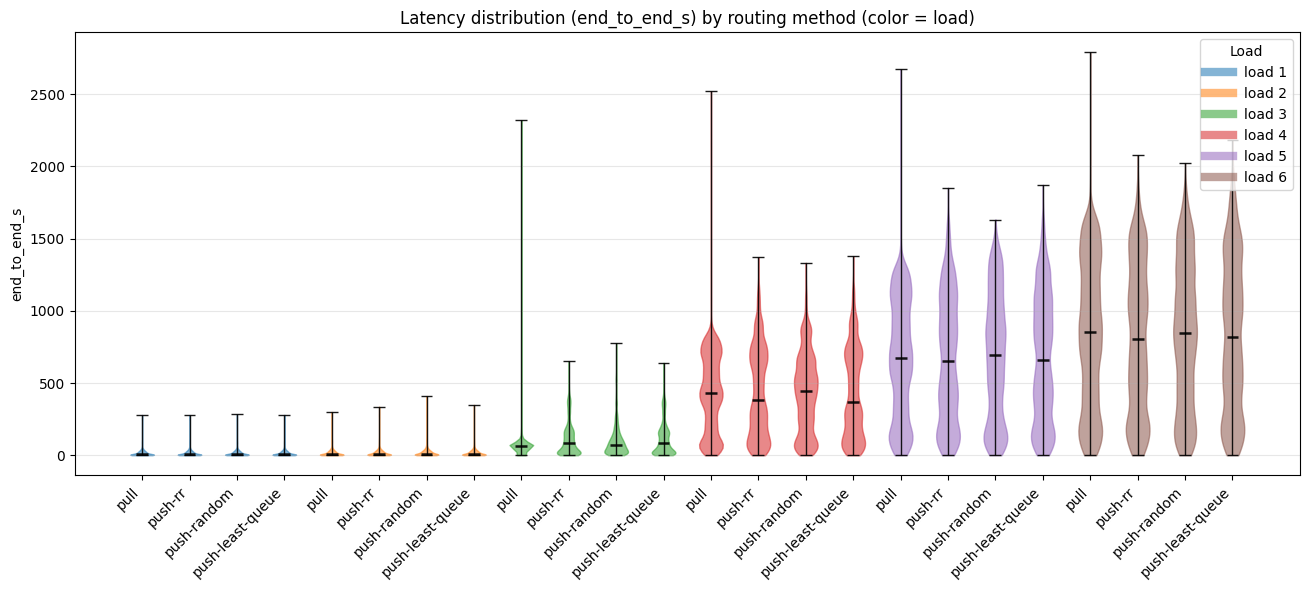

In [44]:
from experiment_analysis import load_experiment_latencies
import pandas as pd
import matplotlib.pyplot as plt
import os

# ---- choose series (one or more) ----
series_ids = [33, 34, 35, 36, 37, 38]
# ------------------------------------

# ---- map series id -> friendly name (your load levels) ----
series_display_name = {
    33: "load 1",
    34: "load 2",
    35: "load 3",
    36: "load 4",
    37: "load 5",
    38: "load 6",
}

# ---- within each series, which experiments to include? ----
exp_indices_in_series = [0, 1, 2, 3]

# ---- map exp index -> method name (fixed ordering within each series) ----
method_display_name = {
    0: "pull",
    1: "push-rr",
    2: "push-random",
    3: "push-least-queue",
}
# ------------------------------------

# ---- choose ONE latency metric (uncomment exactly one) ----
metric = "end_to_end_s"
# metric = "server_roundtrip_s"
# metric = "router_queue_s"
# metric = "vllm_compute_s"
# ------------------------------------

# Optional: clip extreme tail for nicer violins (set None to disable)
clip_pctl = None

# Style knobs
VIOLIN_ALPHA = 0.55
EDGE_ALPHA = 0.9
MEDIAN_LW = 1.8
EXTREMA_LW = 1.0

# -------------------- helper: resolve series -> experiments --------------------
series_to_exps = {}
for sid in series_ids:
    exps = list(experiments_from_series([sid]))
    if not exps:
        print(f"Skipping series {sid}: no experiments found")
        continue
    series_to_exps[sid] = exps

# -------------------- collect data --------------------
rows = []
labels = []          # x-axis labels (METHOD ONLY)
series_for_row = []  # which series each violin belongs to
method_for_row = []  # method index (0..3) for ordering/ticks

for sid in series_ids:
    if sid not in series_to_exps:
        continue

    exps = series_to_exps[sid]

    for i in exp_indices_in_series:
        if i < 0 or i >= len(exps):
            continue

        exp_id = exps[i]
        method_name = method_display_name.get(i, f"e{i}")

        df = load_experiment_latencies(exp_id=exp_id)
        if df.empty or metric not in df.columns:
            continue

        s = pd.to_numeric(df[metric], errors="coerce").dropna()
        if s.empty:
            continue

        if clip_pctl is not None:
            hi = s.quantile(clip_pctl / 100.0)
            s = s[s <= hi]

        rows.append(s.values)
        labels.append(method_name)      # <-- method only
        series_for_row.append(sid)
        method_for_row.append(i)

if not rows:
    raise RuntimeError("No experiments had usable latency data for the selected metric.")

# -------------------- plot violins --------------------
fig_w = max(12, 0.55 * len(rows))
plt.figure(figsize=(fig_w, 6))
ax = plt.gca()

positions = list(range(1, len(rows) + 1))

vp = ax.violinplot(
    rows,
    positions=positions,
    showmeans=False,
    showmedians=True,
    showextrema=True
)

# Color by load (series)
unique_series = [sid for sid in series_ids if sid in series_to_exps]
color_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
if not color_cycle:
    color_cycle = ["C0", "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9"]
series_to_color = {sid: color_cycle[i % len(color_cycle)] for i, sid in enumerate(unique_series)}

for body, sid in zip(vp["bodies"], series_for_row):
    c = series_to_color[sid]
    body.set_facecolor(c)
    body.set_edgecolor(c)
    body.set_alpha(VIOLIN_ALPHA)
    body.set_linewidth(1.0)

# Median / extrema styling
if "cmedians" in vp:
    vp["cmedians"].set_color("black")
    vp["cmedians"].set_linewidth(MEDIAN_LW)
    vp["cmedians"].set_alpha(EDGE_ALPHA)

for k in ("cmins", "cmaxes", "cbars"):
    if k in vp:
        vp[k].set_color("black")
        vp[k].set_linewidth(EXTREMA_LW)
        vp[k].set_alpha(EDGE_ALPHA)

# ---- X axis: show METHOD labels, repeated per violin ----
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha="right")

ax.set_ylabel(metric)
title = f"Latency distribution ({metric}) by routing method (color = load)"
if clip_pctl is not None:
    title += f" (clipped above p{clip_pctl})"
ax.set_title(title)

ax.grid(True, axis="y", alpha=0.3)

# Legend: load → color (friendly names)
handles = []
legend_labels = []
for sid in unique_series:
    load_name = series_display_name.get(sid, f"series {sid}")
    h = plt.Line2D([0], [0], color=series_to_color[sid], lw=6, alpha=VIOLIN_ALPHA)
    handles.append(h)
    legend_labels.append(load_name)

ax.legend(handles, legend_labels, loc="upper right", title="Load")

plt.tight_layout()


os.makedirs("figures", exist_ok=True)

measure_name = "dist"   # distribution (violin)
fname = f"figures/{measure_name}_{metric}_by_method_by_load.png"
plt.savefig(fname, dpi=300, bbox_inches="tight")

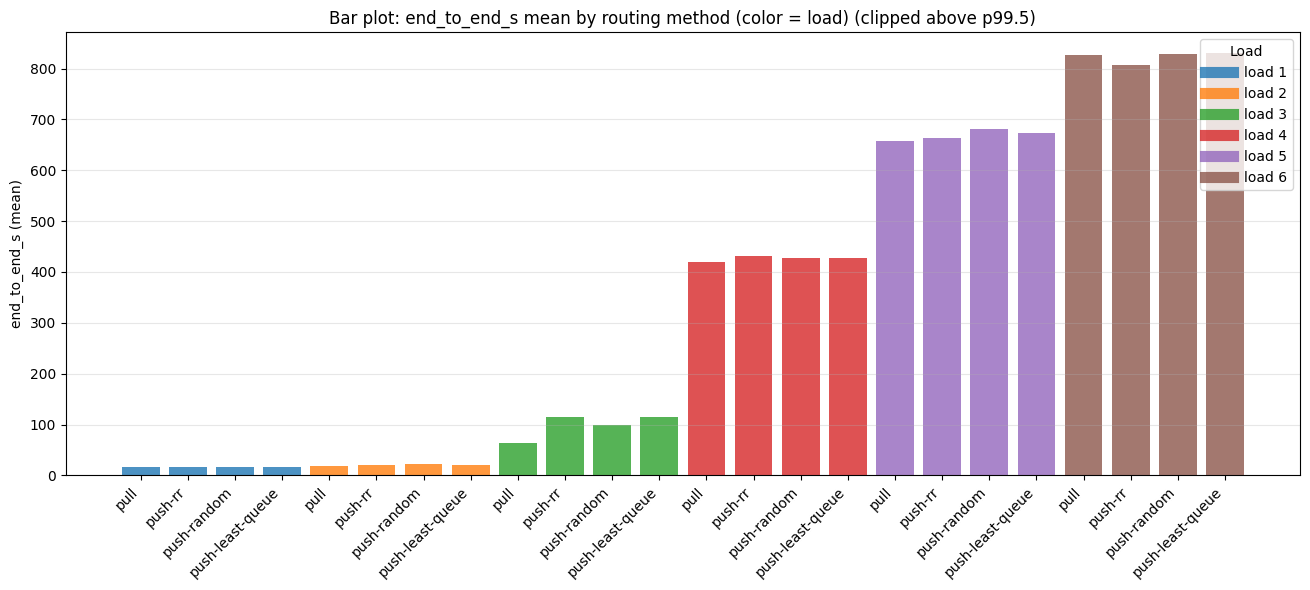

In [43]:
from experiment_analysis import load_experiment_latencies
import pandas as pd
import matplotlib.pyplot as plt
import os


# ---- choose series (one or more) ----
series_ids = [33, 34, 35, 36, 37, 38]
# ------------------------------------

# ---- map series id -> friendly name (your load levels) ----
series_display_name = {
    33: "load 1",
    34: "load 2",
    35: "load 3",
    36: "load 4",
    37: "load 5",
    38: "load 6",
}

# ---- within each series, which experiments to include? ----
exp_indices_in_series = [0, 1, 2, 3]

# ---- map exp index -> method name (fixed ordering within each series) ----
method_display_name = {
    0: "pull",
    1: "push-rr",
    2: "push-random",
    3: "push-least-queue",
}
# ------------------------------------

# ---- choose ONE latency metric (uncomment exactly one) ----
metric = "end_to_end_s"
# metric = "server_roundtrip_s"
# metric = "router_queue_s"
# metric = "vllm_compute_s"
# ------------------------------------

# ---- choose ONE stat at a time ----
stat_to_plot = "mean"     # <- pick ONE: "50%", "90%", "99%", "mean", etc.

# Optional: clip extreme tail before computing stats (set None to disable)
clip_pctl = 99.5  # e.g. 99.5; or None

# -------------------- resolve series -> experiments --------------------
series_to_exps = {}
for sid in series_ids:
    exps = list(experiments_from_series([sid]))
    if not exps:
        print(f"Skipping series {sid}: no experiments found")
        continue
    series_to_exps[sid] = exps

# -------------------- compute stat per experiment --------------------
records = []  # each: {series, method_idx, method, value}

for sid in series_ids:
    if sid not in series_to_exps:
        continue

    exps = series_to_exps[sid]

    for i in exp_indices_in_series:
        if i < 0 or i >= len(exps):
            print(f"Skipping series {sid} exp_index {i}: out of range (len={len(exps)})")
            continue

        exp_id = exps[i]
        df = load_experiment_latencies(exp_id=exp_id)

        if df.empty or metric not in df.columns:
            print(f"Skipping series {sid} exp_index {i}: no data or missing {metric}")
            continue

        s = pd.to_numeric(df[metric], errors="coerce").dropna()
        if s.empty:
            print(f"Skipping series {sid} exp_index {i}: {metric} all NaN")
            continue

        if clip_pctl is not None:
            hi = s.quantile(clip_pctl / 100.0)
            s = s[s <= hi]

        # Compute exactly the stat requested
        if stat_to_plot.endswith("%"):
            q = float(stat_to_plot.strip("%")) / 100.0
            val = float(s.quantile(q))
        else:
            if stat_to_plot == "mean":
                val = float(s.mean())
            elif stat_to_plot == "std":
                val = float(s.std())
            elif stat_to_plot == "min":
                val = float(s.min())
            elif stat_to_plot == "max":
                val = float(s.max())
            else:
                raise ValueError("stat_to_plot must be a percentile like '90%' or one of: mean, std, min, max")

        records.append({
            "series": sid,
            "method_idx": i,
            "method": method_display_name.get(i, f"e{i}"),
            "value": val,
        })

if not records:
    raise RuntimeError("No experiments had usable latency data for the selected metric/stat.")

plot_df = pd.DataFrame.from_records(records)

# Order bars: by series_ids, then method order
series_rank = {sid: r for r, sid in enumerate(series_ids)}
plot_df["series_rank"] = plot_df["series"].map(series_rank)
plot_df = plot_df.sort_values(["series_rank", "method_idx"]).reset_index(drop=True)

# X-axis labels: METHOD ONLY (no series/load, no exp id)
x_labels = plot_df["method"].tolist()

# -------------------- color by series (load) --------------------
unique_series = [sid for sid in series_ids if sid in plot_df["series"].unique()]
color_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
if not color_cycle:
    color_cycle = ["C0", "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9"]
series_to_color = {sid: color_cycle[j % len(color_cycle)] for j, sid in enumerate(unique_series)}

colors = [series_to_color[sid] for sid in plot_df["series"].tolist()]

# -------------------- plot --------------------
fig_w = max(12, 0.55 * len(plot_df))
plt.figure(figsize=(fig_w, 6))
ax = plt.gca()

x = list(range(len(plot_df)))
ax.bar(x, plot_df["value"].values, color=colors, alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha="right")
ax.set_ylabel(f"{metric} ({stat_to_plot})")

title = f"Bar plot: {metric} {stat_to_plot} by routing method (color = load)"
if clip_pctl is not None:
    title += f" (clipped above p{clip_pctl})"
ax.set_title(title)

ax.grid(True, axis="y", alpha=0.3)

# Legend: load → color (friendly names)
handles = []
legend_labels = []
for sid in unique_series:
    load_name = series_display_name.get(sid, f"series {sid}")
    h = plt.Line2D([0], [0], color=series_to_color[sid], lw=8, alpha=0.8)
    handles.append(h)
    legend_labels.append(load_name)

ax.legend(handles, legend_labels, loc="upper right", frameon=True, title="Load")

plt.tight_layout()

measure_name = stat_to_plot.replace("%", "").lower()
if stat_to_plot.endswith("%"):
    measure_name = f"p{measure_name}"   # "99%" -> "p99"
# else: "mean", "std", "min", "max" stay as-is

fname = f"figures/{measure_name}_{metric}_by_method_by_load.png"
plt.savefig(fname, dpi=300, bbox_inches="tight")
